# Ploynomial Regression

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler

In [174]:
df = pd.read_csv("/kaggle/input/datasets/atifmazhar/salary/Salary Data.csv")

## Data Preprocessing

In [175]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [176]:
df.shape

(375, 6)

In [177]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [179]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [180]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [181]:
# df["Age"] = df["Age"].fillna(df["Age"].mean())
df = df.dropna()
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [182]:
print(df.duplicated().sum())

49


In [183]:
# Let's see all duplicated rows
duplicate = df[df.duplicated(keep=False)]
duplicate[:10]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
140,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
209,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
210,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
211,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
212,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
213,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
214,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
215,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
216,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0


In [184]:
df = df.drop_duplicates(keep = "first")
df.duplicated().sum()

np.int64(0)

In [185]:
df.shape

(324, 6)

## Visualization

Text(0.5, 1.0, 'Salary Distribution')

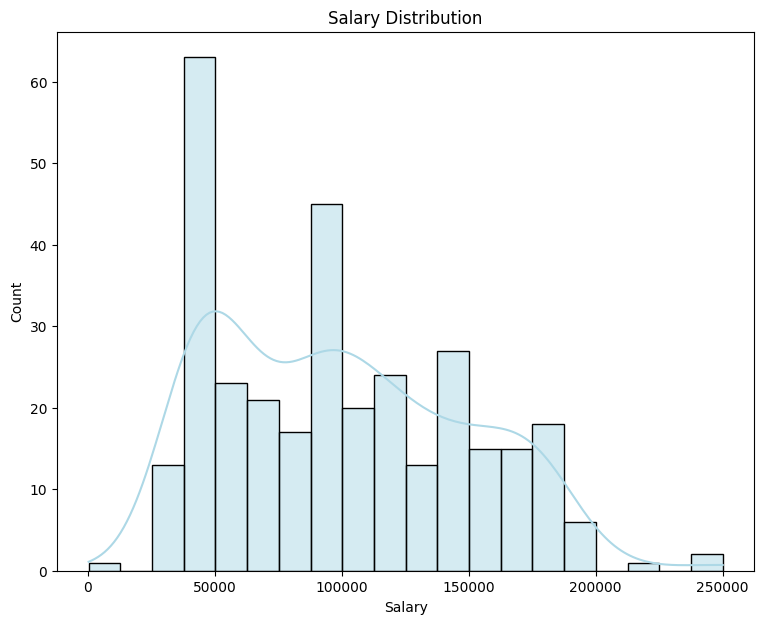

In [186]:
# Let's see target variable distribution
plt.figure(figsize=(9,7))
sns.histplot(data = df,x = "Salary",bins = 20,kde = True,color="lightblue")
plt.title("Salary Distribution")

<Axes: xlabel='Salary', ylabel='Density'>

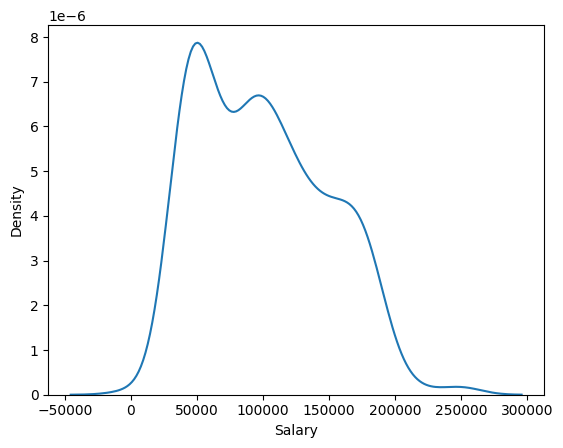

In [187]:
sns.kdeplot(data=df,x="Salary")

<Axes: xlabel='Salary', ylabel='Age'>

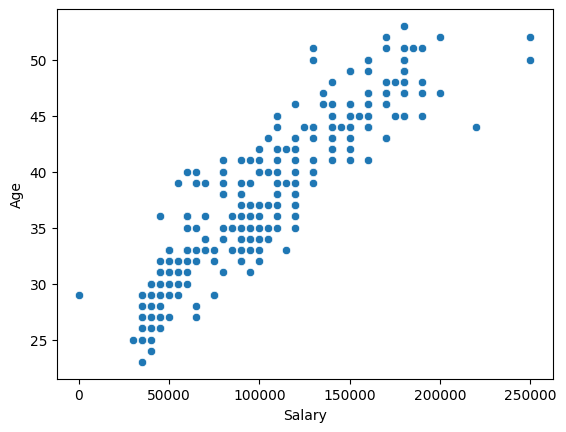

In [188]:
sns.scatterplot(data=df, x= "Salary",y="Age")

## Model Training

In [189]:
X = df.drop("Salary",axis=1)
y = df["Salary"]
X.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')

In [190]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size =0.2,random_state=42)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((259, 5), (259,), (65, 5), (65,))

In [191]:
# Let's find numerical and categorical columns

# 1. Numerical
numeric_features = X_train.select_dtypes(
    include = ["int64", "float64"]
).columns

# 2. Categorical 
categorical_features = X_train.select_dtypes(
    include = ["object","category"]
).columns
numeric_features, categorical_features

(Index(['Age', 'Years of Experience'], dtype='object'),
 Index(['Gender', 'Education Level', 'Job Title'], dtype='object'))

In [192]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [193]:
# # categorical to Numerical -> for no order categorical columns 

# from sklearn.preprocessing import OneHotEncoder

# onehot_encoder = OneHotEncoder(
#     handle_unknown="ignore",
#     sparse_output=False
# )

# X_train_en = onehot_encoder.fit_transform(
#     X_train[["Gender","Job Title"]]
# )




# X_test_en = onehot_encoder.transform(
#     X_test[["Gender","Job Title"]]
# )
# # onehot_encoder.get_feature_names_out()

# # Drop the original columns

# X_train.drop(
#     ["Gender","Job Title"],
#     axis = 1,
#     inplace= True
# )




In [194]:
# X_test.drop(
#     columns = ["Gender","Job Title"],
#     inplace = True
# )
# X_test.head()

In [195]:
# Now add the encoded columns
# X_train[onehot_encoder.get_feature_names_out()] = X_train_en
# X_test[onehot_encoder.get_features_names_out()] = X_test_en

In [196]:
X_train.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')

In [197]:
# categorical to Numerical -> for order categorical columns 

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(
    categories = [["Bachelor's", "Master's", 'PhD']]
)

X_train["Education Level"] = ordinal_encoder.fit_transform(
    X_train[["Education Level"]]
).ravel()

X_test["Education Level"] = ordinal_encoder.transform(
    X_test[["Education Level"]]
).ravel()

In [198]:
X_train.head()

,Age,Gender,Education Level,Job Title,Years of Experience
73,28.0,Male,0.0,Technical Support Specialist,2.0
182,44.0,Female,2.0,Senior UX Designer,15.0
17,39.0,Male,2.0,Senior Engineer,12.0
24,41.0,Male,1.0,Financial Manager,13.0
146,42.0,Female,2.0,Senior Data Scientist,16.0


In [199]:
df["Job Title"].nunique()

174

In [200]:
df["Job Title"].value_counts()

Job Title
Director of Operations            9
Director of Marketing             8
Senior Marketing Manager          8
Senior Project Manager            7
Senior Data Scientist             6
                                 ..
Junior Social Media Specialist    1
Junior Operations Coordinator     1
Senior HR Specialist              1
Director of HR                    1
Junior Financial Advisor          1
Name: count, Length: 174, dtype: int64

In [201]:
# categorical to Numerical -> for no order categorical columns 
X_train = pd.get_dummies(X_train,columns = ["Gender"],dtype = int)
X_test = pd.get_dummies(X_test,columns = ["Gender"],dtype = int)
X_train.head()

,Age,Education Level,Job Title,Years of Experience,Gender_Female,Gender_Male
73,28.0,0.0,Technical Support Specialist,2.0,0,1
182,44.0,2.0,Senior UX Designer,15.0,1,0
17,39.0,2.0,Senior Engineer,12.0,0,1
24,41.0,1.0,Financial Manager,13.0,0,1
146,42.0,2.0,Senior Data Scientist,16.0,1,0


In [202]:
X_test.head()

,Age,Education Level,Job Title,Years of Experience,Gender_Female,Gender_Male
132,40.0,1.0,Senior Training Specialist,12.0,1,0
108,41.0,1.0,Senior Marketing Analyst,14.0,1,0
137,30.0,0.0,Junior Marketing Manager,4.0,1,0
9,38.0,2.0,Senior Scientist,10.0,0,1
181,37.0,1.0,Senior Business Analyst,9.0,0,1


In [203]:
# Now let's drop the job title
X_train.drop("Job Title",axis= 1,inplace = True)
X_train.head()

,Age,Education Level,Years of Experience,Gender_Female,Gender_Male
73,28.0,0.0,2.0,0,1
182,44.0,2.0,15.0,1,0
17,39.0,2.0,12.0,0,1
24,41.0,1.0,13.0,0,1
146,42.0,2.0,16.0,1,0


In [204]:
X_test.drop("Job Title",axis= 1,inplace = True)
X_test.head()

,Age,Education Level,Years of Experience,Gender_Female,Gender_Male
132,40.0,1.0,12.0,1,0
108,41.0,1.0,14.0,1,0
137,30.0,0.0,4.0,1,0
9,38.0,2.0,10.0,0,1
181,37.0,1.0,9.0,0,1


In [205]:
# Let's standardized our data before passing to the Polynomial Model
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[["Age","Years of Experience"]] = scaler.fit_transform(X_train[["Age","Years of Experience"]])

X_test[["Age","Years of Experience"]] = scaler.transform(X_test[["Age","Years of Experience"]])
X_test.head()

,Age,Education Level,Years of Experience,Gender_Female,Gender_Male
132,0.326860,1.0,0.266698,1,0
108,0.464514,1.0,0.565401,1,0
137,-1.049673,0.0,-0.928110,1,0
9,0.051554,2.0,-0.032004,0,1
181,-0.086100,1.0,-0.181355,0,1


In [208]:
# Now let's create Polynomial Features 
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree = 2,
    include_bias= False
)

poly_features = ["Age","Education Level","Years of Experience"]

X_train_poly = poly.fit_transform(
    X_train[poly_features]
)

X_test_poly = poly.transform(
    X_test[poly_features]
)
X_train_poly.shape

(259, 9)

In [207]:
poly.get_feature_names_out(poly_features)

array(['Age', 'Education Level', 'Years of Experience', 'Age^2',
       'Age Education Level', 'Age Years of Experience',
       'Education Level^2', 'Education Level Years of Experience',
       'Years of Experience^2'], dtype=object)

In [209]:
# Now let's create Dataframe

poly_columns = poly.get_feature_names_out(poly_features)

X_train_poly = pd.DataFrame(
    X_train_poly,
    columns = poly_columns,
    index = X_train.index
)

X_test_poly = pd.DataFrame(
    X_test_poly,
    columns = poly_columns,
    index = X_test.index
)

In [211]:
X_train_poly.head()


,Age,Education Level,Years of Experience,Age^2,Age Education Level,Age Years of Experience,Education Level^2,Education Level Years of Experience,Years of Experience^2
73,-1.324980,0.0,-1.226813,1.755571,-0.000000,1.625502,0.0,-0.000000,1.505069
182,0.877474,2.0,0.714752,0.769960,1.754947,0.627176,4.0,1.429503,0.510870
17,0.189207,2.0,0.266698,0.035799,0.378414,0.050461,4.0,0.533397,0.071128
24,0.464514,1.0,0.416049,0.215773,0.464514,0.193261,1.0,0.416049,0.173097
146,0.602167,2.0,0.864103,0.362605,1.204334,0.520334,4.0,1.728205,0.746674


In [212]:
# Other than polynomial features columns
X_train_other = X_train[["Gender_Female","Gender_Male"]]
X_test_other = X_test[["Gender_Female","Gender_Male"]]

In [213]:
# Combine both poly features and other features

X_train = pd.concat(
    [X_train_poly,X_train_other],
    axis = 1
)

X_test = pd.concat(
    [X_test_poly,X_test_other],
    axis= 1
)

X_train.head()



,Age,Education Level,Years of Experience,Age^2,Age Education Level,Age Years of Experience,Education Level^2,Education Level Years of Experience,Years of Experience^2,Gender_Female,Gender_Male
73,-1.324980,0.0,-1.226813,1.755571,-0.000000,1.625502,0.0,-0.000000,1.505069,0,1
182,0.877474,2.0,0.714752,0.769960,1.754947,0.627176,4.0,1.429503,0.510870,1,0
17,0.189207,2.0,0.266698,0.035799,0.378414,0.050461,4.0,0.533397,0.071128,0,1
24,0.464514,1.0,0.416049,0.215773,0.464514,0.193261,1.0,0.416049,0.173097,0,1
146,0.602167,2.0,0.864103,0.362605,1.204334,0.520334,4.0,1.728205,0.746674,1,0


In [214]:
X_train.shape

(259, 11)

In [215]:
# Let's fit the Linear Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

In [219]:
# Let's see the parameter
print(lr.coef_)

print("\n",lr.intercept_)

[ 19369.10421457  27147.87033112  20193.37355337  18223.42108208
   2510.21687899 -29018.56414458  -7018.74756787  -1267.7491707
  10432.56050188  -4028.31189976   4028.31189976]

 91116.59561979682


## Model Evaluation


In [220]:
y_pred = lr.predict(X_test)
y_pred[:5]

array([119575.67568773, 127727.05729924,  48810.43527263, 122164.90349764,
       109983.07361843])

In [222]:
y_test.values[:5]

array([100000., 100000.,  50000., 110000., 105000.])

In [223]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("Mae :",mae)
print("\n Mse : ",mse)
print("\nRmse: ",rmse)
print("\nR2_score: ",r2)

Mae : 10552.096401837653

 Mse :  202556466.78583854

Rmse:  14232.233373080928

R2_score:  0.8928151856857267


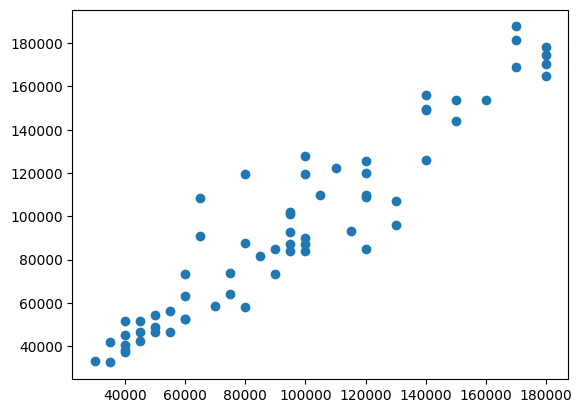

In [224]:
plt.scatter(y_test,y_pred)

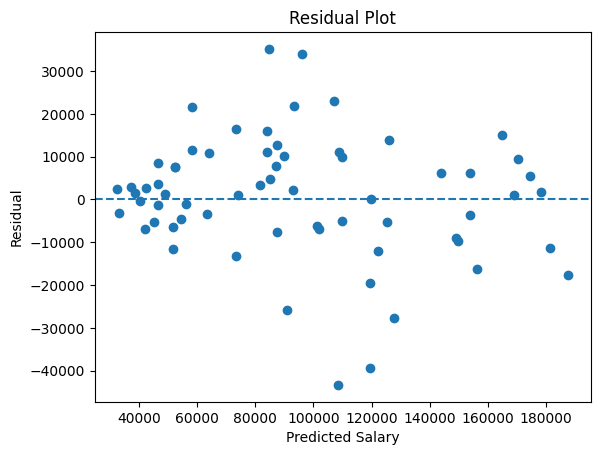

In [227]:
residual = y_test-y_pred
plt.scatter(y_pred,residual)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()